## OPTIMIZACIÓN NO LINEAL-Red Neuronal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import pandas as pd

In [ ]:
m=np.array([2,2,1]) # (dimx,num neuronas capa oculta,num neuronas de salida)
def IniciarPesos(m):
  W=[]
  for i in range(1,len(m)):
    W.append(np.zeros((m[i],m[i-1]+1)))
  return W

In [ ]:
W=IniciarPesos(m)
list(map(lambda M:(type(M),M.shape),W))

[(numpy.ndarray, (2, 3)), (numpy.ndarray, (1, 3))]

### Función de activación
Función tangente sigmoidal

In [ ]:
c=2
def activacion(z):
  y=np.tanh(c*z)
  return y

def NeuralNetwork(W,X):               #=f(w,x)
  y=np.zeros(X.shape[1])
  for j in range(X.shape[1]):
    phi0=np.hstack([1,X[:,j]]) # Datos de entrenamiento pegandole un 1
    W1=W[0]  # PESOS SINAPTICOS DE LA CAPA OCULTA
    phi1=np.hstack([1,activacion(W1@phi0)])
    W2=W[1]  # PESOS SINAPTICOS DE LA CAPA DE SALIDA
    phi2=activacion(W2@phi1)
    y[j]=phi2[0] 
  return y


### Datos de prueba

$ y=|x|+1/2 $; $ y=|x|-1/2$

In [ ]:
n=50
np.random.seed(0)
X1=[]       #Clase +1
while len(X1)<n:
  X,Y=np.random.uniform(-3,3,2)
  if Y<abs(X)-0.5:
    X1.append([X,Y])
X1=np.array(X1)
Y1=np.ones(n)

X2=[]       #Clase -1
while len(X2)<n:
  X,Y=np.random.uniform(-4,4,2)
  if Y>abs(X)+0.5:
    X2.append([X,Y])
X2=np.array(X2)
Y2=-np.ones(n)

In [ ]:
X=np.vstack([X1,X2])
Y=np.hstack([Y1,Y2])

#W=np.array([[0,-1,-1],[0,1,-1]]),np.array([[-1,1,1]]
W=[np.array([[0,1,-1],[0,-1,-1]]),
   np.array([[1,1,1]])
   ]

In [ ]:
Y2=NeuralNetwork(W,X.T) #define la red neuronal
pfit=np.mean(np.sign(Y)==np.sign(Y2))*100
print(f"Clasificación :{pfit:.2f}%")


Clasificación :100.00%


/tmp/ipython-input-3830573050.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  zz[i,j]=NeuralNetwork(W,x)


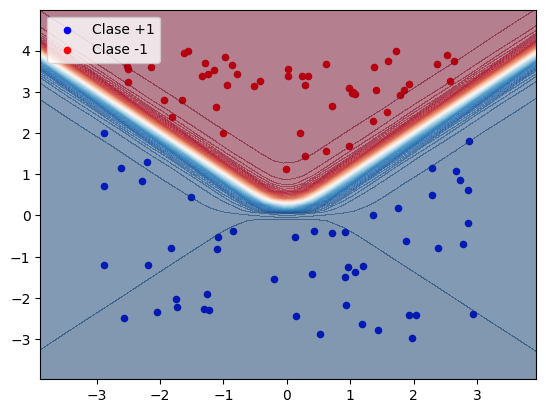

In [ ]:
X1=X[:,0]
X2=X[:,1]
npoints=50
# Crear malla para curvas de nivel
xx,yy=np.meshgrid(np.linspace(X1.min()-1,X1.max()+1,npoints),
                  np.linspace(X2.min()-1,X2.max()+1,npoints))
zz=np.zeros((npoints,npoints))
for i in range(npoints):
  for j in range(npoints):
    x=np.array([[xx[i,j]],[yy[i,j]]])
    zz[i,j]=NeuralNetwork(W,x)
# Graficar datos
plt.scatter(X1[Y==1],X2[Y==1],c='blue',s=20,label='Clase +1')
plt.scatter(X1[Y==-1],X2[Y==-1],c='red',s=20,label='Clase -1')
#Curvvas de nivel de la tangente sigmoidal
plt.contourf(xx,yy,zz,levels=100,cmap='RdBu',alpha=0.5)

plt.legend()
plt.show()

### Gradiente red Neuronal

In [ ]:
def GradNeuralNetwork(W,x):
  G=IniciarPesos(m)
  W1=W[0]
  W2=W[1]
  p0=x.ravel()
  phi0=np.hstack([1,p0])
  p1=activacion(W1@phi0)#salida capa oculta
  phi1=np.hstack([1,p1])
  p2=activacion(W2@phi1)#Capa de salida (shape (1,))
  phi2=p2

  for j in range(len(x)):
    # Correct W2 index: W2[0,0] is bias, W2[0,1] for p1[0], W2[0,2] for p1[1]
    G[0][j,:]=c**2*W2[0,j]*(1-p2**2)*(1-p1[j]**2)*phi0

  G[1][0,:]=c**2*(1-p2**2)*phi1.T # phi1.T is just phi1 for 1D array, and p2[0] extracts scalar

  return G

In [ ]:
#función merito de mínimos cuadrados
def fls(W,X,y):
  p=NeuralNetwork(W,X)
  return float(0.5*np.sum((p-y)**2))

def gradls(W,X,y):
  G=IniciarPesos(m)
  #recorrer cada uno de los datos
  for j in range(X.shape[1]):
    yj=NeuralNetwork(W,X[:,[j]])
    gj=GradNeuralNetwork(W,X[:,[j]])
    G[0]=G[0]+(yj-y[j])*gj[0] #Actualizamos el gradiente de la función de minimos respecto al gradiente de la capa oculta
    G[1]=G[1]+(yj-y[j])*gj[1] #'' respecto al gradiente de la capa de salida
  return G

In [ ]:
def descenso_grad(f,gf,w0,tol=1e-6,maxiter=2000):
  w=w0#pesos de la red neuronal
  fx=f(w)
  for k in range(maxiter):
    gx=gf(w)
    d=[-gx[i] for i in range(len(gx))]
    ngx=max([np.linalg.norm(gx[i],ord=np.inf) for i in range(len(gx))])
    if ngx<tol:
      break
    paso=0.01
    w = [w[i]+paso*d[i] for i in range(len(d))]
    fx=f(w)
  return w,fx,k,ngx

In [ ]:
def f(w):
  return fls(w,X.T,Y)

def gf(w):
  return gradls(w,X.T,Y)

In [ ]:
W0 = [
np.array([[-4, 1, -1],[0, -2, 1]]), # capa oculta 2x3
np.array([[1, -1, 1]]) # capa salida 1x3
]
WS, F, iter, n2g = descenso_grad(f, gf, W0)
print('Red Neuronal:')
print('Grad Red Neuronal:')
G = GradNeuralNetwork(W,X[0,:].T)
print('------------------------')
y2 = NeuralNetwork(W,X.T)
pfit = np.mean(np.sign(Y) == np.sign(y2)) *100
print(f"Clasificación :{pfit:.2f}%")
print('Iteraciones:',iter)
print('Norma del gradiente:',n2g)
print('Valor Objetivo 0:',f(W0))

Red Neuronal:
Grad Red Neuronal:
------------------------
Clasificación :100.00%
Iteraciones: 1999
Norma del gradiente: 0.00962569719353142
Valor Objetivo 0: 108.29682543521376


#Otro ejemplo

In [ ]:
def PrintPesos(W):
  print('Capa oculta:')
  print(W[0])
  print('Capa salida:')
  print(W[1])

In [ ]:
W0 = [
 np.array([[1, 0, 1],[1, 1, 0]]),
 np.array([[1, 1, 1]])
 ]
WS, F, iter, n2g = descenso_grad(f, gf, W0)
PrintPesos(W0)
y2 = NeuralNetwork(WS,X.T)
pfit = np.mean(np.sign(Y) == np.sign(y2)) * 100
print("Iteraciones :", iter)
print("Norma del gradiente:", n2g)
print("Valor Objetivo 0 :", f(W0))
print("Valor Objetivo F :", f(WS))
print(f"Clasificación : {pfit:.2f}%")

Capa oculta:
[[1 0 1]
 [1 1 0]]
Capa salida:
[[1 1 1]]
Iteraciones : 1999
Norma del gradiente: 0.027899931296979347
Valor Objetivo 0 : 114.20046202719958
Valor Objetivo F : 0.0014862079302153319
Clasificación : 100.00%


/tmp/ipython-input-3812261879.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  zz[i,j] = NeuralNetwork(WS,x)


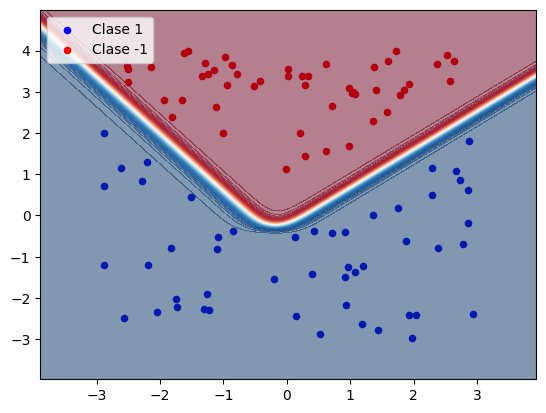

In [ ]:
npoints = 200
# Crear malla para curvas de nivel
xx, yy = np.meshgrid(np.linspace(X1.min()-1, X1.max()+1, npoints),
np.linspace(X2.min()-1, X2.max()+1, npoints))
zz = np.zeros((npoints,npoints))
for i in range(npoints):
  for j in range(npoints):
    x = np.array([[xx[i,j]], [yy[i,j]]])
    zz[i,j] = NeuralNetwork(WS,x)
# Graficar datos
plt.scatter(X1[Y==1], X2[Y==1], c='blue', s=20, label='Clase 1')
plt.scatter(X1[Y==-1], X2[Y==-1], c='red', s=20, label='Clase -1')
# Curvas de nivel de la tangente sigmoidal
plt.contourf(xx, yy, zz, levels=100, cmap='RdBu', alpha=0.5)
plt.legend()
plt.show()